# 01 - Exploratory Data Analysis

Overview of the REST-meta-MDD phenotypic data before any modeling.

**Goals**
- Class balance (MDD vs. HC)
- Site distribution and sample sizes
- Age and sex distributions per group
- Missing data audit
- Potential confounders (age, sex, site)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGURES_DIR = "../results/figures"

## 1. Load phenotypic data

In [ ]:
mdd  = pd.read_csv(os.getenv("RAW_DATA_PATH_PHENOTYPE") + "/REST-meta-MDD-PhenotypicData_WithHAMDSubItem_V4_MDD.csv")
ctrl = pd.read_csv(os.getenv("RAW_DATA_PATH_PHENOTYPE") + "/REST-meta-MDD-PhenotypicData_WithHAMDSubItem_V4_CONTROL.csv")

mdd["diagnosis"]  = 1
ctrl["diagnosis"] = 0

shared_cols = ["subject_id", "diagnosis", "Sex", "Age", "Education (years)"]
df = pd.concat([mdd[shared_cols], ctrl[shared_cols]], ignore_index=True)

df["site"] = df["subject_id"].str.extract(r"^(S\d+)-")

print(f"Total subjects : {len(df)}")
print(f"MDD            : {(df.diagnosis==1).sum()}")
print(f"HC             : {(df.diagnosis==0).sum()}")
df.head()

Total subjects : 2380
MDD            : 1276
HC             : 1104


,subject_id,diagnosis,Sex,Age,Education (years),site
0,S1-1-0001,1,2,36,18.0,S1
1,S1-1-0002,1,2,28,15.0,S1
2,S1-1-0003,1,2,55,11.0,S1
3,S1-1-0004,1,2,48,8.0,S1
4,S1-1-0005,1,1,21,13.0,S1


## 2. Class balance

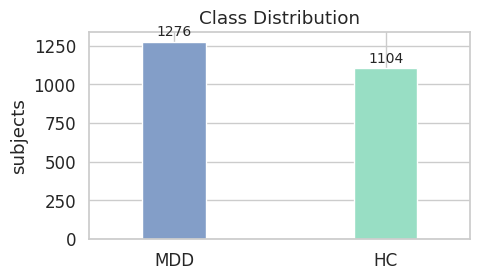

Imbalance ratio: 1.16


In [30]:
counts = df["diagnosis"].value_counts().rename({0: "HC", 1: "MDD"})

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind="bar", ax=ax, color=["#839EC8", "#98DEC4"], width=0.3)
ax.bar_label(ax.containers[0], fmt="%d", padding=2, fontsize=10)
ax.set_title("Class Distribution")
ax.set_ylabel("subjects")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_class_balance.png", dpi=150)
plt.show()

print(f"Imbalance ratio: {counts.max()/counts.min():.2f}")

## 3. Site distribution

Multi-site data introduces scanner/protocol variability — a major confound  
in neuroimaging studies. This plot shows sample size and MDD ratio per site.

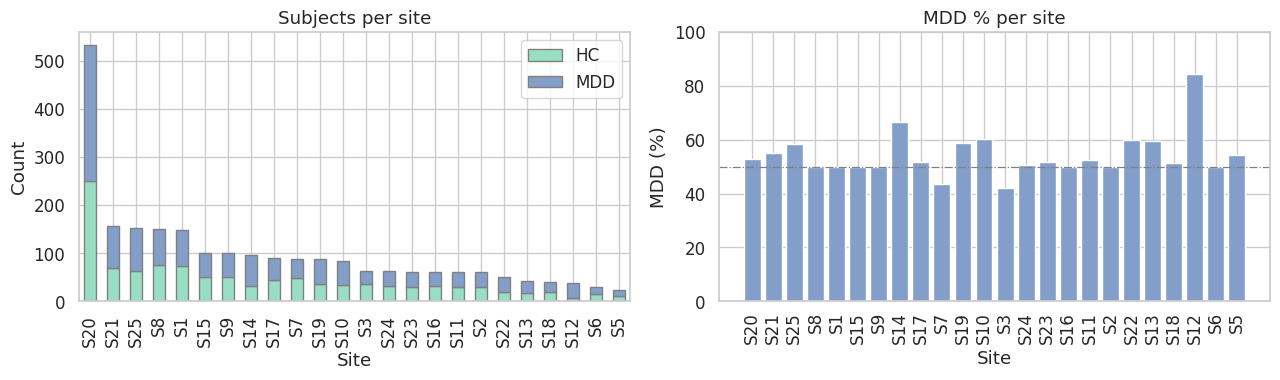

      total  mdd   hc    mdd_pct
site                            
S20     533  282  251  52.908068
S21     156   86   70  55.128205
S25     152   89   63  58.552632
S8      150   75   75  50.000000
S1      148   74   74  50.000000
S15     100   50   50  50.000000
S9      100   50   50  50.000000
S14      96   64   32  66.666667
S17      91   47   44  51.648352
S7       87   38   49  43.678161
S19      87   51   36  58.620690
S10      83   50   33  60.240964
S3       64   27   37  42.187500
S24      63   32   31  50.793651
S23      62   32   30  51.612903
S16      62   31   31  50.000000
S11      61   32   29  52.459016
S2       60   30   30  50.000000
S22      50   30   20  60.000000
S13      42   25   17  59.523810
S18      41   21   20  51.219512
S12      38   32    6  84.210526
S6       30   15   15  50.000000
S5       24   13   11  54.166667


In [58]:
site_stats = (
    df.groupby("site")["diagnosis"]
    .agg(total="count", mdd="sum")
    .assign(hc=lambda d: d["total"] - d["mdd"],
            mdd_pct=lambda d: 100 * d["mdd"] / d["total"])
    .sort_values("total", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked bar — HC vs MDD per site
site_stats[["hc", "mdd"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=["#98DEC4", "#839EC8"], edgecolor="gray"
)
axes[0].set_title("Subjects per site")
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(["HC", "MDD"])

# Right: MDD percentage per site
axes[1].bar(site_stats.index, site_stats["mdd_pct"],
            color="#839EC8", edgecolor="white")
axes[1].axhline(50, color="gray", linestyle="dashdot", linewidth=0.9)
axes[1].set_title("MDD % per site")
axes[1].set_xlabel("Site")
axes[1].set_ylabel("MDD (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=90, size=4)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_site_distribution.png", dpi=150)
plt.show()

print(site_stats.to_string())

## 4. Age and sex by group

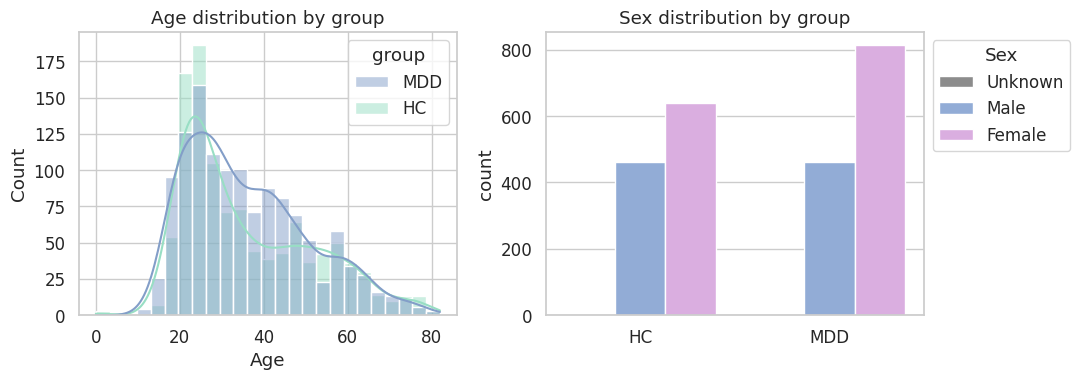

,mean,std,min,max
group,,,,
HC,36.2,15.7,0,80
MDD,36.2,14.6,12,82


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
label_map = {0: "HC", 1: "MDD"}
df["group"] = df["diagnosis"].map(label_map)

sns.histplot(
    data=df, x="Age", hue="group", bins=25,
    kde=True, ax=axes[0],
    palette={"HC": "#98DEC4", "MDD": "#839EC8"}
)
axes[0].set_title("Age distribution by group")

sex_counts = (
    df.groupby(["group", "Sex"])
    .size()
    .reset_index(name="count")
)
sex_counts["Sex"] = sex_counts["Sex"].map({1: "Male", 2: "Female", 0: "Unknown"})
sns.barplot(
    data=sex_counts, x="group", y="count", hue="Sex",
    ax=axes[1],
    palette={"Male": "#86A9E2", "Female": "#E0A6E8", "Unknown": "#8C8C8C"}
)
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))
axes[1].set_title("Sex distribution by group")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_age_sex.png", dpi=150)
plt.show()

df.groupby("group")["Age"].agg(["mean", "std", "min", "max"]).round(1)

## 5. Potential confounders

Age and sex differences between MDD and HC can confound classification.  
If significant, they should be regressed out or controlled in the model.

In [41]:
from scipy import stats

mdd_age  = df.loc[df.diagnosis == 1, "Age"].dropna()
ctrl_age = df.loc[df.diagnosis == 0, "Age"].dropna()

t_stat, p_age = stats.ttest_ind(mdd_age, ctrl_age)
print(f"Age — MDD: {mdd_age.mean():.1f} ± {mdd_age.std():.1f}")
print(f"Age — HC : {ctrl_age.mean():.1f} ± {ctrl_age.std():.1f}")
print(f"t-test   : t={t_stat:.2f}, p={p_age:.4f}")
print()

# Sex: chi-square test
sex_table = pd.crosstab(df["diagnosis"], df["Sex"])
chi2, p_sex, _, _ = stats.chi2_contingency(sex_table)
print(f"Sex — chi2={chi2:.2f}, p={p_sex:.4f}")
print()
if p_age < 0.05 or p_sex < 0.05:
    print(" Significant demographic differences detected.")
    print(" Consider including Age and Sex as covariates in the model.")
else:
    print("✓  No significant demographic differences.")

Age — MDD: 36.2 ± 14.6
Age — HC : 36.2 ± 15.7
t-test   : t=0.13, p=0.8981

Sex — chi2=8.96, p=0.0113

 Significant demographic differences detected.
 Consider including Age and Sex as covariates in the model.
